# **FTL099 INTELIGÊNCIA ARTIFICIAL APLICADA 2026/1**  
# Trabalho 01: Regressão Linear com Múltiplas Variáveis  

Aluno: Nycksandro Lima dos Santos  
Matrícula: 22351228

## **Introdução**
O presente trabalho apresenta uma aplicação de Regressão Linear com Múltiplicas Variáveis para predição da pressão maxima de um paciente, dadas as 4 variavéis a seguir: sexo, idade, peso, fumante/não fumante.

#### **Possíveis aplicações**

* **Triagem Inteligente:** Em hospitais com muitos pacientes, um modelo de regressão pode priorizar quem deve ser atendido primeiro com base no risco estimado de hipertensão, antes mesmo de passar pela enfermagem.  

* **Monitoramento por Wearables:** Relógios inteligentes usam regressão para estimar a pressão arterial ou o oxigênio no sangue usando apenas sensores de luz.  

#### **Trabalhos similares**

Foi realizada uma breve busca por trabalhos similares na literatura, e foram selecionados 2 artigos:

* **A new machine learning method for predicting systolic and diastolic blood pressure using clinical characteristics**

  O artigo científico [2] apresenta um novo método de aprendizado de máquina para prever as pressões arteriais sistólica e diastólica com base em características clínicas e hábitos de vida. Os pesquisadores utilizaram uma base de dados com 50.000 registros para treinar modelos que consideram variáveis como idade, peso, tabagismo e níveis de colesterol. Foram testados quatro algoritmos distintos: KNN, regressão logística, árvore de decisão e random forest.
  
  O estudo conclui que o modelo de random forest atingiu o nível mais alto de precisão e eficiência computacional. Essa abordagem busca facilitar o diagnóstico precoce da hipertensão, reduzindo a necessidade de equipamentos caros ou intervenção humana constante.

* **A Linear Regression Model with Dynamic Pulse Transit Time Features for Noninvasive Blood Pressure Prediction**

  O estudo de Hsieh et al. [3] propõe um modelo de regressão linear (LR) aprimorado para a predição não invasiva das pressões arterial sistólica (SBP) e diastólica (DBP). A principal inovação do método consiste na inclusão de características dinâmicas (como inclinação e curvatura) extraídas do Tempo de Trânsito do Pulso (PTT), além das características estáticas convencionais.

  Os autores também introduziram uma abordagem onde o valor estimado da pressão sistólica é utilizado como parâmetro adicional para aumentar a precisão na predição da pressão diastólica. Testado com dados da base MIMIC, o modelo proposto (LR-SD) demonstrou desempenho superior aos métodos tradicionais, apresentando maiores coeficientes de correlação (R2) e menores erros quadráticos médios (MSE).

  Apesar da eficácia, o trabalho ressalta que o modelo possui limitações para capturar oscilações de baixa frequência influenciadas por fatores internos e externos, o que torna a recalibração periódica necessária para manter a acurácia a longo prazo.

## **Metodologia**
Descrever como o experimento foi feito utilizando as 5 pastas: quantos
registros cada pasta terá, como os resultados serão avaliados, mostrar um
fluxograma do programa das etapas da metodologia, etc

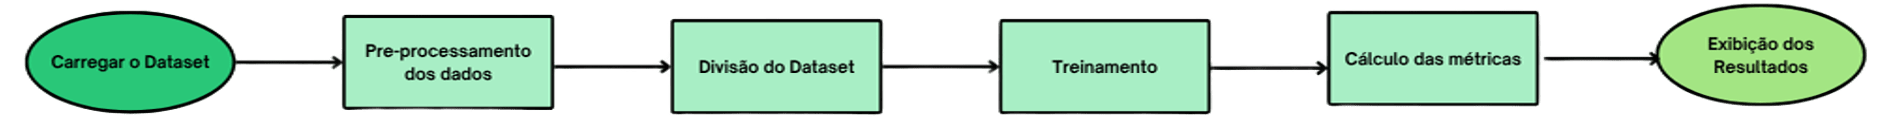

In [1]:
# Importando as bibliotecas necessárias
import pandas as pd
import numpy as np
from sklearn import metrics

### **Etapas realizadas**





1) **Estudo e análise sobre os dados do dataset**   
O primeiro passo realizado no desenvolvimento do trabalho, foi analisar e entender as informações do dataset. O estudo foi realizado observando as disposições das informações das linhas (parte do head), contando a quantidade de valores NaN, e estatísticas das colunas e chegou-se na conclusão que seria necessário fazer um pré-processamento dos dados.

In [2]:
dataframe = pd.read_excel("./hospital.xls") # Carregando o dataframe
print(dataframe.head())

        ID  LastName     Sex  Age  Weight  Smoker  BloodPressure_1  \
0  YPL-320     SMITH    Male   38     176    True              124   
1  GLI-532   JOHNSON    Male   43     163   False              109   
2  PNI-258  WILLIAMS  Female   38     131   False              125   
3  MIJ-579     JONES  Female   40     133   False              117   
4  XLK-030     BROWN  Female   49     119   False              122   

   BloodPressure_2  Trials_1  Trials_2  Trials_3  Trials_4  
0               93      18.0       NaN       NaN       NaN  
1               77      11.0      13.0      22.0       NaN  
2               83       NaN       NaN       NaN       NaN  
3               75       6.0      12.0       NaN       NaN  
4               80      14.0      23.0       NaN       NaN  


In [3]:
# Aqui eu printo algumas informações que levantei do dataframe
print(f"\nInformações da coluna {dataframe["Sex"].value_counts()}\n")
print(f"\nInformações da coluna {dataframe["Smoker"].value_counts()}\n")
print(f"\nIdade média: {dataframe["Age"].mean(0, True)}\n")
print(f"\nPeso médio: {dataframe['Weight'].mean(0, True)}\n")

print(f"\nElementos NaN por cada coluna (em %)\n{dataframe.isnull().mean()*100}\n") # Obtém a porcentagem de números NaN em cada coluna
print(f"\nElementos NaN nas colunas Trials_1,2,3 e 4 simultâneamente (em %): {dataframe[["Trials_1","Trials_2","Trials_3","Trials_4"]].all(axis=0).sum()}\n") # Obtém a porcentagem de números NaN em cada coluna


Informações da coluna Sex
Female    53
Male      47
Name: count, dtype: int64


Informações da coluna Smoker
False    66
True     34
Name: count, dtype: int64


Idade média: 38.28


Peso médio: 154.0


Elementos NaN por cada coluna (em %)
ID                  0.0
LastName            0.0
Sex                 0.0
Age                 0.0
Weight              0.0
Smoker              0.0
BloodPressure_1     0.0
BloodPressure_2     0.0
Trials_1           24.0
Trials_2           63.0
Trials_3           83.0
Trials_4           96.0
dtype: float64


Elementos NaN nas colunas Trials_1,2,3 e 4 simultâneamente (em %): 4



2) **Pré-processamento dos dados: Parte 01**  

* Limpeza dos Dados: As colunas "Trials_1", "Trials_2", "Trials_3" e "Trials_4" foram eliminadas por possuir muitos NaN e por não ser relevantes para predição dap pressão maxima. Além disso, como será utilizado somente as 4 variáveis, "Sexo", "Fumante/Não Fumante", "Peso" e "Idade". As colunas "LastName", "ID" e "BloodPressure_2", mantendo somente as 4 variáveis e a pressão arterial máxima.

* Codificação: Transformar as variáveis categóricas "Sexo" em binárias (0/1). A coluna "Smoker" já está númerica (0 ou 1).

In [4]:
dataframe_v2 = dataframe.copy().drop(["Trials_1","Trials_2","Trials_3","Trials_4", "LastName", "ID", "BloodPressure_2"], axis=1) # Eliminando essas 6 colunas e deixando somente as 5 colunas necessárias para a regressão
dataframe_v2 = pd.get_dummies(dataframe_v2, columns=["Sex"]) # Torna a variável "Sex" que era categorica em númerica (0 ou 1)
print(dataframe_v2.head())

   Age  Weight  Smoker  BloodPressure_1  Sex_Female  Sex_Male
0   38     176    True              124       False      True
1   43     163   False              109       False      True
2   38     131   False              125        True     False
3   40     133   False              117        True     False
4   49     119   False              122        True     False


3) **Divisão do Dataset**
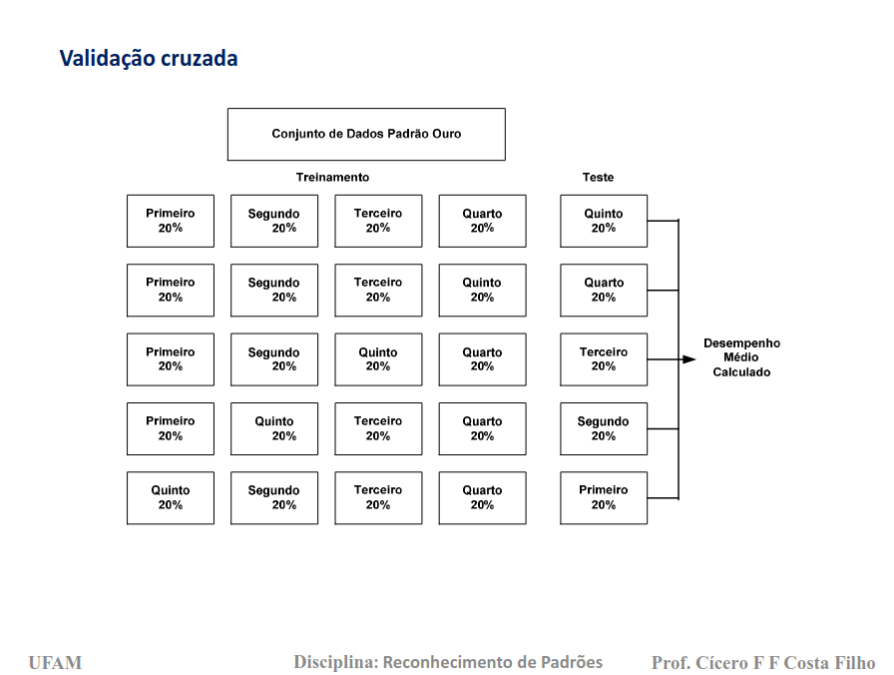

Figura 1 – Ilustração de exemplo de validação cruzada. Fonte: [1].



A divisão do dataset foi realizada seguindo a distribuição da Figura 1.

Como o dataset possui 100 registros e é necessário dividir em 5 partições (4 de treino e 1 de teste) com 20 % dos registros cada, o número de registros que cada partição terá será de 20 registros.

In [5]:
# Dividir ele em 5 conforme a figura

primeiro = dataframe_v2.iloc[0:20].copy()
segundo = dataframe_v2.iloc[20:40].copy()
terceiro = dataframe_v2.iloc[40:60].copy()
quarto = dataframe_v2.iloc[60:80].copy()
quinto = dataframe_v2.iloc[80:100].copy()

dataframes_dicionario = {1:primeiro, # Dicionario pra facilitar a correspondencia na ordem
            2:segundo,
            3:terceiro,
            4: quarto,
            5: quinto}

ordem = [([1, 2, 3, 4], 5), ([1, 2, 3, 5], 4), ([1, 2, 5, 4], 3), ([1, 5, 3, 4], 2), ([5, 2, 3 ,4], 1)] # Ordem correspondente a divisão do dataset

**4. Pré-processamento dos dados: Parte 02**  

* Normalização: Ajustar a escala de Idade, Peso, Pressão Arterial 1 e. Essa etapa foi realizada após a divisão dos datasets para evitar *Data Leakage*. Ao realizar essa etapa antes da divisão, o bloco de treino já vai conhecer qual é a média global (que inclui os dados do Teste), e isso inviesaria o treino.

A ideia para normalizar cada coluna é substituir o valor original (x), pelo valor normalizado (z), que se dá pela diferença do valor original com a média da coluna, dividido pelo desvio padrão da coluna.

  # $z = \frac{x - \mu}{\sigma}$

* x: Valor original.

* μ (mu): Média da coluna.

* σ (sigma): Desvio padrão da coluna.

In [6]:
# Normalizando as colunas númericas

colunas_para_normalizar = ["Age" , "Weight", "BloodPressure_1"] # Colunas que precisam ser normalizadas

def normalizar_dataframe_treino(dataframe, colunas_para_normalizar): # Função que recebe um dataset (panda) e as colunas que precisam ser normalizadas, e normaliza o dataset de acordo com as informações da 3 etapa
  lista_medias = []
  lista_desvio_padrao = []

  for coluna in colunas_para_normalizar:
    media = dataframe[coluna].mean() # Calcula a média da coluna
    desvio_padrao = dataframe[coluna].std() # Calcula o desvio padrão da coluna
    lista_medias.append(media) # Adiciono na lista de médias
    lista_desvio_padrao.append(desvio_padrao) # Adiciono na lista de desvio padrão

    dataframe[coluna] = (dataframe[coluna] - media) / desvio_padrao # Calculo o valor normalizado e substituo

  return (lista_medias,lista_desvio_padrao) # Retorno a lista de médias e de desvio padrão

def normalizar_dataframe_teste(dataframe, colunas_para_normalizar, lista_media, lista_desvio_padrao): # Função que recebe um dataset (panda), as colunas, a média da partição de treino e desvio padrão da partição de treino, e normaliza o dataset de acordo com as informações da 3 etapa
  for i in range(len(colunas_para_normalizar)):
    media = lista_media[i] # a média da coluna correspondente
    desvio_padrao = lista_desvio_padrao[i] # desvio padrão da coluna correspondente
    coluna = colunas_para_normalizar[i]

    dataframe[coluna] = (dataframe[coluna] - media) / desvio_padrao # Calculo o valor normalizado e substituo



In [7]:
def pseudo_inversa(x_train, x_test, y_train): # Definida no notebook jupyter de exemplo de Regressão Linear do drive da disciplina
  bias = np.ones(shape=(len(x_train),1))
  x_train = np.hstack((x_train, bias))
  #x_train.shape

  bias = np.ones(shape=(len(x_test),1))
  x_test = np.hstack((x_test, bias))
  #x_test.shape

  x_train_t = x_train.transpose()

  w = np.linalg.pinv(x_train) @ y_train
  w = w.reshape(len(w),1)
  w_t = w.transpose()
  #w_t.shape

  x_test = x_test.transpose()
  x_test.shape
  #w.shape
  y_pred = w_t@x_test
  y_pred = y_pred.transpose()
  #y_pred.shape

  return y_pred

In [8]:
def treinamento_adaline(X, y, eta=0.01, epochs=50):
    X_aug = np.c_[np.ones(X.shape[0]), X] # Bias: Coluna de 1's na matriz X

    w = np.zeros(X_aug.shape[1]) # Inicializa os pesos com zeros

    mse_lista = [] # Lista para guardar o erro (MSE) de cada época e plotar depois

    for _ in range(epochs):
        saida = X_aug @ w # y_pred = X * w
        erros = y - saida # Cálculo do erro

        # Atualizando os pesos(Regra de Delta):
        w += eta * X_aug.T @ erros / X_aug.shape[0]  # w = w + eta * X.T * erro

        # Calcula o MSE da época para o relatório
        mse = np.mean(erros**2)
        mse_lista.append(mse)

    return w, mse_lista

def predito_adaline(X, w):
    X_aug = np.c_[np.ones(X.shape[0]), X] # Adiciona a coluna de 1s (bias) no início ou fim
    return X_aug @ w # faz a predição

**5. Treinando**

In [9]:
# Aplicando a pseudo_inversa

"""
Abaixo será aplicado o método da pseudo_inversa utilizando validação cruzada de 5 pastas
"""
particao_atual = 1
lista_mse_pi = []
lista_pearson_pi = []


for (part_treino, part_teste) in ordem:
  # Separo os dataframes de Treino e Teste conforme especificado na etapa 3 acima

  print(f"\n--------------RESULTADO DA PARTIÇÃO {particao_atual}--------------\n")

  x_treino = pd.concat([dataframes_dicionario[i] for i in part_treino]) # Usei lista por compreensão para gerar uma lista que substitui os valores númericos pelos valores chaves do dicionario. Dessa forma, consigo concatenar de forma correta as partes conforme a figura.
  x_teste = dataframes_dicionario[part_teste].copy()

  media_treino, desvio_padrao_treino = normalizar_dataframe_treino(x_treino, colunas_para_normalizar) # Normalizo o a partição de treino e obtenho a média e desvio padrão do mesmo
  normalizar_dataframe_teste(x_teste, colunas_para_normalizar, media_treino, desvio_padrao_treino) # Normalizo a partição de teste utilizando como média e desvio padrão da partição de treino

  y_treino = x_treino.copy()["BloodPressure_1"] # Coletando a partição de y de treino
  x_treino.drop(columns=["BloodPressure_1"], inplace=True)  # Retirando as colunas correspondente a y_treino, do cojunto de treino x

  y_teste_real = x_teste.copy()["BloodPressure_1"] # Coletando a partição de y de teste
  x_teste.drop(columns=["BloodPressure_1"], inplace=True)  # Retirando as colunas correspondente a y_teste_real, do cojunto de teste x

  # Convertendo para vetor numpy para aplicar no método da pseudo_inversa
  y_teste_real = y_teste_real.astype(float).to_numpy()
  x_treino = x_treino.astype(float).to_numpy()
  x_teste = x_teste.astype(float).to_numpy()
  y_treino = y_treino.astype(float).values

  y_predito = pseudo_inversa(x_treino, x_teste, y_treino) # Aplico a pseudo_inversa
  mse = metrics.mean_squared_error(y_teste_real, y_predito) # Calculo o MSE
  pearson = np.corrcoef(y_teste_real.flatten(), y_predito.flatten())[0, 1] # Calculo o coeficiente de Pearson. Também usei flatten para garantir que eles fiquem no formato (N,)

  lista_mse_pi.append(mse) # Adiciono o mse obtido na lista de mse
  lista_pearson_pi.append(pearson) # Adiciono o mse obtido na lista de de pearson

  # Eu printo o resultado de cada treinamento
  print(f"Mean Squared Error (MSE): {mse:.4f}") # Valores esperados, valores dados
  print(f"Coeficiente de Pearson: {pearson:.4f}")
  particao_atual +=1


--------------RESULTADO DA PARTIÇÃO 1--------------

Mean Squared Error (MSE): 0.9710
Coeficiente de Pearson: 0.5277

--------------RESULTADO DA PARTIÇÃO 2--------------

Mean Squared Error (MSE): 0.4366
Coeficiente de Pearson: 0.5703

--------------RESULTADO DA PARTIÇÃO 3--------------

Mean Squared Error (MSE): 0.3966
Coeficiente de Pearson: 0.8816

--------------RESULTADO DA PARTIÇÃO 4--------------

Mean Squared Error (MSE): 0.4131
Coeficiente de Pearson: 0.7249

--------------RESULTADO DA PARTIÇÃO 5--------------

Mean Squared Error (MSE): 0.5283
Coeficiente de Pearson: 0.6498


In [10]:
# Aplicando o treinamento

"""
Abaixo será aplicado o treinamento utilizando validação cruzada de 5 pastas
"""
particao_atual = 1
lista_mse_treinamento = []
lista_pearson_treinamento = []


for (part_treino, part_teste) in ordem:
  # Separo os dataframes de Treino e Teste conforme especificado na etapa 3 acima

  print(f"\n--------------TREINAMENTO DA PARTIÇÃO {particao_atual}--------------\n")

  x_treino = pd.concat([dataframes_dicionario[i] for i in part_treino]) # Usei lista por compreensão para gerar uma lista que substitui os valores númericos pelos valores chaves do dicionario. Dessa forma, consigo concatenar de forma correta as partes conforme a figura.
  x_teste = dataframes_dicionario[part_teste].copy()

  media_treino, desvio_padrao_treino = normalizar_dataframe_treino(x_treino, colunas_para_normalizar) # Normalizo o a partição de treino e obtenho a média e desvio padrão do mesmo
  normalizar_dataframe_teste(x_teste, colunas_para_normalizar, media_treino, desvio_padrao_treino) # Normalizo a partição de teste utilizando como média e desvio padrão da partição de treino

  y_treino = x_treino.copy()["BloodPressure_1"] # Coletando a partição de y de treino
  x_treino.drop(columns=["BloodPressure_1"], inplace=True)  # Retirando as colunas correspondente a y_treino, do cojunto de treino x

  y_teste_real = x_teste.copy()["BloodPressure_1"] # Coletando a partição de y de teste
  x_teste.drop(columns=["BloodPressure_1"], inplace=True)  # Retirando as colunas correspondente a y_teste_real, do cojunto de teste x

  # Convertendo para vetor numpy para aplicar no método da pseudo_inversa
  y_teste_real = y_teste_real.astype(float).to_numpy()
  x_treino = x_treino.astype(float).to_numpy()
  x_teste = x_teste.astype(float).to_numpy()
  y_treino = y_treino.astype(float).values

  pesos_finais, lista_mse = treinamento_adaline(x_treino, y_treino, eta=0.01, epochs=15000)
  y_predito = predito_adaline(x_teste, pesos_finais)

  mse = metrics.mean_squared_error(y_teste_real, y_predito) # Calculo o MSE
  pearson = np.corrcoef(y_teste_real.flatten(), y_predito.flatten())[0, 1] # Calculo o coeficiente de Pearson. Também usei flatten para garantir que eles fiquem no formato (N,)

  lista_mse_treinamento.append(mse) # Adiciono o mse obtido na lista de mse
  lista_pearson_treinamento.append(pearson) # Adiciono o mse obtido na lista de de pearson

  # Eu printo o resultado de cada treinamento
  print(f"Mean Squared Error (MSE): {mse:.4f}") # Valores esperados, valores dados
  print(f"Coeficiente de Pearson: {pearson:.4f}")
  particao_atual +=1


--------------TREINAMENTO DA PARTIÇÃO 1--------------

Mean Squared Error (MSE): 0.9709
Coeficiente de Pearson: 0.5277

--------------TREINAMENTO DA PARTIÇÃO 2--------------

Mean Squared Error (MSE): 0.4365
Coeficiente de Pearson: 0.5704

--------------TREINAMENTO DA PARTIÇÃO 3--------------

Mean Squared Error (MSE): 0.3965
Coeficiente de Pearson: 0.8817

--------------TREINAMENTO DA PARTIÇÃO 4--------------

Mean Squared Error (MSE): 0.4131
Coeficiente de Pearson: 0.7249

--------------TREINAMENTO DA PARTIÇÃO 5--------------

Mean Squared Error (MSE): 0.5283
Coeficiente de Pearson: 0.6498


## **Resultados**

Os resultados obtidos em cada aplicação da pseudo inversa e do treinamento serão avaliados apartir de 2 métricas: MSE (Mean Square Error) e Coeficiente de Pearson.

### **Métricas**

#### **MSE**

Erro Médio Quadrático é a função de custo fundamental para o treinamento do algoritmo Adaline. Ele quantifica a performance do modelo calculando a média aritmética dos quadrados das diferenças entre os valores reais (y) e as saídas estimadas ($\hat{y}$). Para o experimento foi utilizado a implementação da bibioteca sklearn a partir do módulo metrics.


#### **Pearson**  

O Coeficiente de Pearson é uma medida estatística que quantifica o grau de relação linear entre duas variáveis quantitativas. No contexto deste trabalho, ele é utilizado para avaliar a correlação entre as características do paciente (variáveis independentes) e a pressão arterial sistólica (variável dependente).

In [11]:
print(f"\n-------------------RESULTADO FINAl COM PSEUDO_INVERSA-------------------\n") # Calculo a média com desvio padrão dos 5 treinos realizados
print(f"MSE Médio: {np.mean(lista_mse_pi):.4f} ± {np.std(lista_mse_pi):.4f}")
print(f"Coeficiente de Pearson Médio: {np.mean(lista_pearson_pi):.4f} ± {np.std(lista_pearson_pi):.4f}")


-------------------RESULTADO FINAl COM PSEUDO_INVERSA-------------------

MSE Médio: 0.5491 ± 0.2158
Coeficiente de Pearson Médio: 0.6709 ± 0.1252


In [12]:
print(f"\n-------------------RESULTADO FINAl COM ADALINE-------------------\n") # Calculo a média com desvio padrão dos 5 treinos realizados
print(f"MSE Médio: {np.mean(lista_mse_treinamento):.4f} ± {np.std(lista_mse_treinamento):.4f}")
print(f"Coeficiente de Pearson Médio: {np.mean(lista_pearson_treinamento):.4f} ± {np.std(lista_pearson_treinamento):.4f}")


-------------------RESULTADO FINAl COM ADALINE-------------------

MSE Médio: 0.5490 ± 0.2158
Coeficiente de Pearson Médio: 0.6709 ± 0.1252


## **Referência Bibliográficas**

[1] F F COSTA, Cícero. Divisão de dados: Validação cruzada. Amazonas: Universidade Federal do Amazonas (UFAM), 2026. Slides apresentados na disciplina de Inteligência Artificial Aplicada.  

[2] Shrivastava, A., Chakkaravarthy, M., & Shah, M. A. (2023). A new machine learning method for predicting systolic and diastolic blood pressure using clinical characteristics. Healthcare Analytics, 4, 100219.

[3] Hsieh, Y. Y., Wu, C. D., Lu, S. S., & Tsao, Y. (2016, October). A linear regression model with dynamic pulse transit time features for noninvasive blood pressure prediction. In 2016 IEEE biomedical circuits and systems conference (BioCAS) (pp. 604-607). IEEE.